Som vanligt importerar vi för alla paket som behövs.

In [1]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

Vi kommer nu undersöka ML-skattning av parametrar för en [logistisk regressionsmodell](https://sv.wikipedia.org/wiki/Enkel_logistisk_regression). I denna har vi ett antal fixa (inte slumpmässiga) mätpunkter $x_1, x_2, \ldots, x_n \in \mathbb{R}$ där varje mätpunkt $x_i$ har en etikett $y_i \in \{0, 1\}$. Vi antar att denna etikett är ett utfall av en Bernoullifördelad stokastisk variabel $Y_i$ vars parameter beror på $x_i$ enligt en viss relation. Mer formellt har vi
$$
    Y_i \sim \text{Ber}(p_i) \quad \text{där } \log\left(\frac{p_i}{1-p_i}\right) = \beta_0 + \beta_1 x_i
$$
för $i = 1, 2, \ldots, n$ där $\beta_0, \beta_1 \in \mathbb{R}$ är modellens parametrar. Med andra ord säger vi att log-oddsen för $p_i$ är linjära (tekniskt sett affina) i $x_i$.

Funktionen
$$
    p \mapsto \log\left(\frac{p}{1-p}\right)
$$
kallas *logitfunktionen* (eller log-oddsfunktionen) och dess invers, den *logistiska funktionen*, ges av
$$
    \alpha \mapsto \frac{1}{1 + e^{-\alpha}} = \frac{e^{\alpha}}{1 + e^{\alpha}} = 1 - \frac{1}{1 + e^{\alpha}}.
$$
Vi kan alltså skriva
$$
    p_i = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x_i)}}
$$

Målet med denna modell är alltså att skatta parametrarna $\beta_0$ och $\beta_1$ utifrån datapunkterna $(x_1, Y_1), (x_2, Y_2), \ldots, (x_n, Y_n)$. Notera återigen att slumpmässigheten endast finns i hur etiketterna $Y_i$ modelleras och att mätpunkterna $x_i$ antas vara fixa. Vi kan tänkta oss att det finns en osäkerhet i vilken klass (noll eller ett) som en mätpunkt $x_i$ ska associeras med, men att själva mätpunkten $x_i$ är helt känd.

Vi börjar med att välja några värden på parametrarna $\beta_0$ och $\beta_1$ samt intervallet våra $x_i$ kommer ligga i.

In [2]:
beta0_true = -1
beta1_true = 8

x_min, x_max = -1, 1

Som innan måste vi generera lite syntetiska data för att testa vår metod. Ett stickprov på $n = 50$ räcker bra här. Vi låter mätpunkterna vara jämnt utspridda i intervallet $[x_\text{min}, x_\text{max}]$. Sedan beräknar vi sannolikheterna $p_i$ associerade med varje mätpunkt $x_i$. Denna kommer ges av den logistiska funktionen ovan tillämpad på $\beta_0 + \beta_1 x_i$ eftersom vi specificerade att log-oddsen ska vara lika med $\beta_0 + \beta_1 x_i$. Till slut använder vi dessa sannolikheter för att generera etiketterna $y_1, y_2, \ldots, y_n$.

In [3]:
n = 50

xs = np.linspace(x_min, x_max, n)
ps = 1 / (1 + np.exp(-(beta0_true + beta1_true * xs)))

ys = np.array([stats.bernoulli.rvs(p) for p in ps])

Nu undersöker vi hur etiketterna fördelat sig för de olika mätpunkterna. Notera att det inte är en skarp övergång, även när $p_i$ är litet finns en viss chans att $Y_i = 1$ och vice versa för $p_i$ stort. Dessa mätpunkter representerar gränsfall där en mätpunkt skulle kunna hamna i båda klasser.

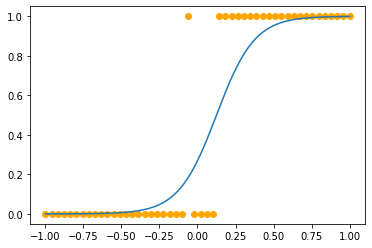

In [4]:
x_grid = np.linspace(x_min, x_max, 256)

plt.plot(x_grid, 1 / (1 + np.exp(-(beta0_true + beta1_true * x_grid))))
plt.scatter(xs, ys, facecolor='orange')
plt.show()

Nu ska vi tillämpa gradientsökning för att ta fram Ml-skattningen för $\beta_0$ och $\beta_1$. Logaritmen av täthetsfunktionen ges av
$$
    \begin{split}
        \log f_{Y_i}(y_i \mid \beta_0, \beta_1) &= \log p_i^{y_i} (1-p_i)^{1-y_i} \\
        &= \log (1-p_i) \left(\frac{p_i}{1-p_i}\right)^y_i \\
        &= \log (1-p_i) + y_i \log \left(\frac{p_i}{1-p_i}\right) \\
        &= - \log (1 + e^{\beta_0 + \beta_1 x_i}) + y_i(\beta_0 + \beta_1 x_i). 
    \end{split}
$$
Den normaliserade log-likelihoodfunktionen blir alltså
$$
    \frac{1}{n} \ell(\beta_0, \beta_1 \mid \mathbf{y}) = \frac{1}{n} \sum_{i=1}^n y_i(\beta_0 + \beta_1 x_i) - \log(1+e^{\beta_0 + \beta_1 x_i}).
$$
Om vi deriverar med avseende på $\beta_0$ får vi
$$
    \frac{1}{n} \frac{\partial \ell}{\partial \beta_0}(\beta_0, \beta_1 \mid \mathbf{y}) = \frac{1}{n} \sum_{i=1}^n y_i - \frac{e^{\beta_0 + \beta_1 x_i}}{1 + e^{\beta_0 + \beta_1 x_i}} = \frac{1}{n} \sum_{i=1}^n y_i - p_i
$$
medan derivatan med avseende på $\beta_1$ blir
$$
  \frac{1}{n} \frac{\partial \ell}{\partial \beta_1}(\beta_0, \beta_1 \mid \mathbf{y}) = \frac{1}{n} \sum_{i=1}^n y_i x_i - \frac{e^{\beta_0 + \beta_1 x_i}}{1 + e^{\beta_0 + \beta_1 x_i}} x_i = \frac{1}{n} \sum_{i=1}^n x_i (y_i - p_i)
$$

Sätter vi ihop dessa får vi gradienten som sedan kan användas under gradientsökningen.

In [5]:
max_iter = 1000
step_size = 5

beta0_ests = []
beta1_ests = []

beta0_ests.append(0.)
beta1_ests.append(0.)

for _ in range(max_iter):
    beta0_est = beta0_ests[-1]
    beta1_est = beta1_ests[-1]
    
    beta0_grad = 0.
    beta1_grad = 0.
    
    for x, y in zip(xs, ys):
        p = 1 / (1 + np.exp(-(beta0_est + beta1_est * x)))
        
        beta0_grad = beta0_grad + (y - p) / n
        beta1_grad = beta1_grad + x * (y - p) / n
        
    beta0_est = beta0_est + step_size * beta0_grad
    beta1_est = beta1_est + step_size * beta1_grad
    
    beta0_ests.append(beta0_est)
    beta1_ests.append(beta1_est)

Som innan så inspekterar vi hur skattningarna beter sig som funktion av iterationen för att se om vi har konvergens.

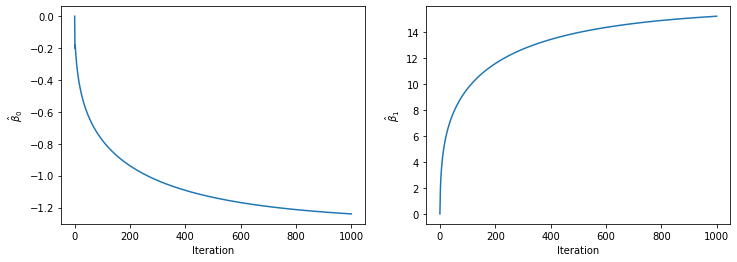

In [6]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(beta0_ests)
plt.xlabel("Iteration")
plt.ylabel(r"$\hat \beta_0$")

plt.subplot(1, 2, 2)
plt.plot(beta1_ests)
plt.xlabel("Iteration")
plt.ylabel(r"$\hat \beta_1$")

plt.show()

Vi kan se hur pass nära våra skattningar är med avseende på de sanna parametervärdena.

In [7]:
print(f"β₀ = {beta0_true}, β₀-hatt = {beta0_ests[-1]}")
print(f"β₁ = {beta1_true}, β₁-hatt = {beta1_ests[-1]}")

β₀ = -1, β₀-hatt = -1.2401398997637105
β₁ = 8, β₁-hatt = 15.199748820768896


Kanske ännu viktigare är att se hur sannolikheterna ser ut som funktion av $x$. Om vi har hittat bra värden på $\beta_0$ och $\beta_1$ borde vi kunna approximera originalfunktionen ganska bra.

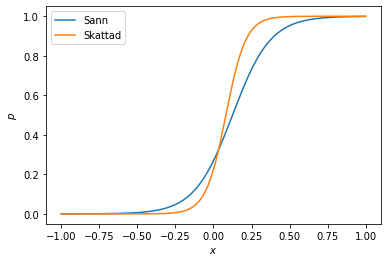

In [8]:
plt.plot(x_grid, 1 / (1 + np.exp(-(beta0_true + beta1_true * x_grid))))
plt.plot(x_grid, 1 / (1 + np.exp(-(beta0_est + beta1_est * x_grid))))
plt.legend(["Sann", "Skattad"])
plt.xlabel(r"$x$")
plt.ylabel(r"$p$")
plt.show()

Vi kan också beräkna $\hat p_i$ för varje $x_i$, dvs. den sannolikhet som vår modell skulle ge mätpunkt $x_i$. Sedan kan vi ta alla mätpunkter som har $p_i < 0.5$ och tilldela dessa etiketten noll, medan resten får etiketten ett.

In [9]:
ps_est = 1 / (1 + np.exp(-(beta0_est + beta1_est * xs)))
ys_est = np.round(ps_est)

Sedan jämför vi detta med de faktiska etiketterna och får på det sättet en kvitto på hur bra vi har lyckats prediktera etiketterna. Notera att det i detta fall inte kommer vara möjligt att nå $100\%$ träffsäkerhet eftersom en del mätpunkter har ”fel” etiketter då de ligger i gränslandet mellan de två klasserna.

In [10]:
accuracy = np.mean(ys_est == ys)
print(f"{accuracy=}")

accuracy=0.96


Logistisk regression generaliseras enkelt till flerdimensionella mätpunkter. Detta betyder att vi har flera faktorer som spelar in för att bestämma sannolikheten $p_i$. Vi antar att $\mathbf{x}_1, \mathbf{x}_2, \ldots, \mathbf{x}_n$ alla har dimension $m$, dvs. är element i $\mathbb{R}^m$, och skriver dem som $\mathbf{x}_i = [x_{ij}]_{j=1}^m$. Vår modell blir då
$$
    Y_i \sim \text{Ber}(p_i) \quad \text{där } \log\left(\frac{p_i}{1-p_i}\right) = \beta_0 + \sum_{j=1}^m \beta_j x_{ij}
$$
för $i = 1, 2, \ldots, n$ med parametrarna $\beta_0, \beta_1, \ldots, \beta_m$. Som innan har vi
$$
    p_i = \frac{1}{1 + e^{-(\beta_0 + \sum_{j=1}^m \beta_j x_{ij})}}.
$$

I det här exemplet tar vi $m = 2$ och väljer några parametervärden.

In [11]:
beta_true = np.array([0.1, 1.9, 2.8])

Nu genererar vi ett stickprov. Först tar vi fram några mätpunkter $\mathbf{x}_1, \mathbf{x}_2, \ldots, \mathbf{x}_n$ genom att slumpa fram några från en standardnormalfördelning. Notera att detta inte betyder att vi modellerar $\mathbf{x}_i$ som slumpmässiga. Detta är bara ett bekvämt sätt att ta fram mätpunkter. Vi skulle kunna göra detta på ett annat sätt utan att det ändrar någonting.

Som innan tar vi sedan fram sannolikheterna $p_1, p_2, \ldots, p_n$ och generar etiketterna $y_1, y_2, \ldots, y_n$ utifrån dessa.

In [12]:
n = 100

xs = stats.norm.rvs(size=(n, len(beta_true) - 1))
ps = np.array([1 / (1 + np.exp(-(beta_true[0] + np.sum(beta_true[1:] * x)))) for x in xs])

ys = np.array([stats.bernoulli.rvs(p) for p in ps])

Vi kan nu plotta mätpunkterna och deras etiketter för att få en överblick i hur klasserna är uppdelade. Notera att det verkar gå en skiljelinje rakt igenom mätpunkterna som separerar klasserna. Detta är för att regressionsmodellen är *linjär*: sannolikheterna $p_i$ ges av en linjär funktion av $\mathbf{x}_i$.

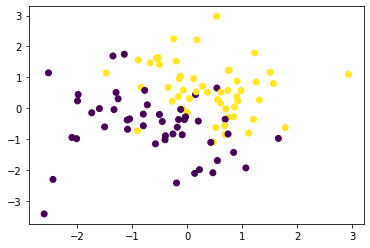

In [13]:
plt.scatter(x=xs[:, 0], y=xs[:, 1], c=ys)
plt.show()

Vi tar fram den normaliserade log-likelihoodfunktionen på samma sätt som innan:
$$
    \frac{1}{n} \ell(\beta_0, \beta_1, \ldots, \beta_m \mid \mathbf{y}) = \frac{1}{n} \sum_{i=1}^n y_i\left(\beta_0 + \sum_{j=1}^m \beta_j x_{ij}\right) - \log\left(1+e^{\beta_0 + \sum_{j=1}^m \beta_j x_{ij}}\right).
$$
Partialderivatorna ges av
$$
    \frac{1}{n} \frac{\partial \ell}{\partial \beta_0}(\beta_0, \beta_1, \ldots, \beta_m \mid \mathbf{y}) = \frac{1}{n} \sum_{i=1}^n y_i - \frac{e^{\beta_0 + \sum_{j=1}^m \beta_j x_{ij}}}{1 + e^{\beta_0 + \sum_{j=1}^m \beta_j x_{ij}}} = \frac{1}{n} \sum_{i=1}^n y_i - p_i
$$
och
$$
  \frac{1}{n} \frac{\partial \ell}{\partial \beta_j}(\beta_0, \beta_1, \ldots, \beta_m \mid \mathbf{y}) = \frac{1}{n} \sum_{i=1}^n y_i x_{ij} - \frac{e^{\beta_0 + \sum_{j=1}^m \beta_j x_{ij}}}{1 + e^{\beta_0 + \sum_{j=1}^m \beta_j x_{ij}}} x_{ij} = \frac{1}{n} \sum_{i=1}^n x_{ij} (y_i - p_i)
$$

In [14]:
max_iter = 1000
step_size = 1

# Initialize arrays
beta_ests = []

# Initial guess
beta_ests.append(np.array([0., 0., 0.]))

for _ in range(max_iter):
    beta_est = beta_ests[-1]
    
    beta_grad = np.zeros_like(beta_est)
    
    for x, y in zip(xs, ys):
        p = 1 / (1 + np.exp(-(beta_est[0] + np.sum(beta_est[1:] * x))))
        
        # Första komponenten (för β₀) är speciell.
        beta_grad[0] = beta_grad[0] + (y - p) / n
        
        # Uppdatera alla andra partialderivator samtidigt.
        beta_grad[1:] = beta_grad[1:] + x * (y - p) / n
        
    beta_est = beta_est + step_size * beta_grad
    
    beta_ests.append(beta_est)
    
beta_ests = np.stack(beta_ests)

Som innan undersöker vi konvergens…

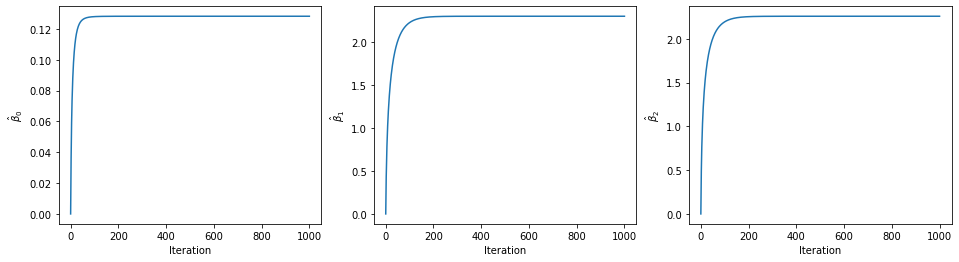

In [15]:
plt.figure(figsize=(16, 4))

plt.subplot(1, 3, 1)
plt.plot(beta_ests[:, 0])
plt.xlabel("Iteration")
plt.ylabel(r"$\hat \beta_0$")

plt.subplot(1, 3, 2)
plt.plot(beta_ests[:, 1])
plt.xlabel("Iteration")
plt.ylabel(r"$\hat \beta_1$")

plt.subplot(1, 3, 3)
plt.plot(beta_ests[:, 2])
plt.xlabel("Iteration")
plt.ylabel(r"$\hat \beta_2$")

plt.show()

…och jämför skattningarna med de sanna värdena.

In [16]:
print(f"β₀ = {beta_true[0]}, β₀-hatt = {beta_ests[-1][0]}")
print(f"β₁ = {beta_true[1]}, β₁-hatt = {beta_ests[-1][1]}")
print(f"β₂ = {beta_true[2]}, β₂-hatt = {beta_ests[-1][2]}")

β₀ = 0.1, β₀-hatt = 0.12828625083093567
β₁ = 1.9, β₁-hatt = 2.2968402236245353
β₂ = 2.8, β₂-hatt = 2.2587094953681244


Vi kan också undersöka sannolikheterna som den skattade modellen predikterar.

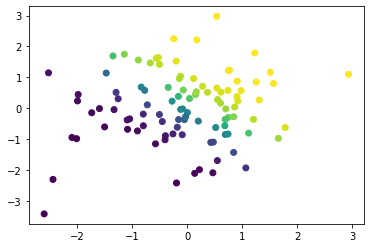

In [17]:
ps_est = [1 / (1 + np.exp(-(beta_est[0] + np.sum(beta_est[1:] * x)))) for x in xs]

plt.scatter(x=xs[:, 0], y=xs[:, 1], c=ps_est)
plt.show()

Som innan kan vi avrunda sannolikheterna för att prediktera etiketterna på mätpunkterna.

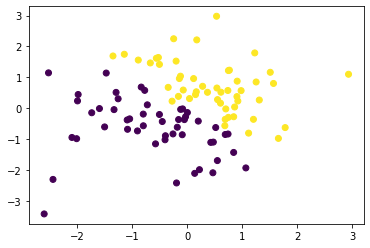

In [18]:
ys_est = np.round(ps_est)

plt.scatter(x=xs[:, 0], y=xs[:, 1], c=ys_est)
plt.show()

Sedan kan vi jämför dessa med de sanna etiketterna.

In [19]:
accuracy = np.mean(ys_est == ys)
print(f"{accuracy=}")

accuracy=0.86


Modellen ovan fungerar för data av godtycklig dimension. Vi kan till exempel låta $\mathbf{x_i}$ vara pixelvärdena i en bild och försöka klassificera denna i en av två klasser. Här har vi två datafiler som innehåller handskrivna ettor och nollor. Alla bilderna är av storlek 28×28, vilket betyder att vi kan representera dem som vektorer av storlek $28 \times 28 = 784$.

In [20]:
# Om du inte har dessa nedladdade, gå in på Canvas och ladda
# ned fls09_data.zip och extrahera filerna från zip-filen.
zeros = np.load("zeros.npy")
ones = np.load("ones.npy")

# Räkna antalet bilder och deras storlek.
n_zeros, height, width = zeros.shape
n_ones, *_ = ones.shape

print(f"Bildstorlek: {width}×{height}")
print(f"Antalet nollor: {n_zeros}")
print(f"Antalet ettor: {n_zeros}")

# Om vi representerar varje bild
dim = height * width
n = n_zeros + n_ones

print(f"Dimension på x-vektor (m): {dim}")
print(f"Antalet mätpunkter (n): {n}")

Bildstorlek: 28×28
Antalet nollor: 5000
Antalet ettor: 5000
Dimension på x-vektor (m): 784
Antalet mätpunkter (n): 10000


Bilderna kan visas med hjälp av `imshow` i Matplotlib.

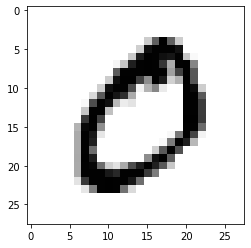

In [21]:
# Istället för färg, använd gråskala (_r gör att den går från
# vitt till svart istället för svart till vitt).
plt.imshow(zeros[0], cmap="gray_r")
plt.show()

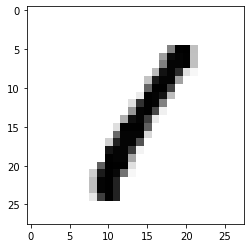

In [22]:
plt.imshow(ones[0], cmap="gray_r")
plt.show()

Vi lägger ihop alla bilderna i en enda stor $\mathbf{x}$-matris och formaterar samtidigt om dem till vektorer av storlek `dim`. Så första axeln motsvarar index i datamängden medan andra axeln motsvarar pixelindex. Sedan konstruerar vi $y$-vektorn av motsvarande etiketter.

In [23]:
xs = np.concatenate((zeros.reshape(n_zeros, dim),
                     ones.reshape(n_ones, dim)))
ys = np.concatenate((np.zeros(n_zeros),
                     np.ones(n_ones)))

Pixelvärden i bilderna är ganska stora, vilket kan leda till att summan $\beta_0 + \sum_{j=1}^m \beta_j x_{ij}$ som vi vill beräkna sedan kan bli ganska stor. När vi exponentierar detta finns en risk att vi får ett väldigt stort eller litet värde (så kallat “overflow” respektive “underflow”). För att undvika detta normaliserar vi bilderna så att varje har norm ett.

In [24]:
xs = xs / np.sqrt(np.sum(xs ** 2, 1, keepdims=True))

# Kolla att det funkade.
print(f"‖x₁‖ = {np.sqrt(np.sum(xs[0] ** 2))}")

‖x₁‖ = 0.9999999999999999


Gradientsökningen blir exakt samma som innan. Skillnaden här är att vi har fler datapunkter ($n = 10000$) och större dimension på $\mathbf{x}$-vektorerna ($m = 784$), så varje iteration tar längre tid.

In [25]:
max_iter = 100
step_size = 1

beta_ests = []

beta_ests.append(np.zeros(dim + 1))

for _ in range(max_iter):
    beta_est = beta_ests[-1]
    
    beta_grad = np.zeros_like(beta_est)
    
    for x, y in zip(xs, ys):
        p = 1 / (1 + np.exp(-(beta_est[0] + np.sum(beta_est[1:] * x))))
        
        beta_grad[0] = beta_grad[0] + (y - p) / n
        beta_grad[1:] = beta_grad[1:] + x * (y - p) / n
        
    beta_est = beta_est + step_size * beta_grad
    
    beta_ests.append(beta_est)
    
beta_ests = np.stack(beta_ests)

Vi kan nu beräkna de skattade sannolikheterna $p_i$ för varje bild $\mathbf{x}_i$ och klassificera bilderna genom att avrunda $p_i$. Träffsäkerheten här är väldigt hög (nära $100\%$) eftersom bilderna skiljer sig så pass mycket att man enkelt kan separara dem linjärt (vilket inte var fallet för våra syntetiska data innan).

In [26]:
ps_est = [1 / (1 + np.exp(-(beta_est[0] + np.sum(beta_est[1:] * x)))) for x in xs]
ys_est = np.round(ps_est)

accuracy = np.mean(ys_est == ys)
print(f"{accuracy=}")

accuracy=0.9961


Vi kan också se vad för sannolikhet varje individuell bild får.

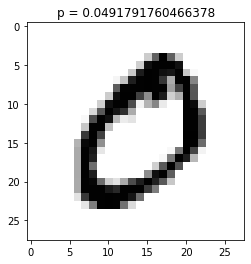

In [27]:
# Kom ihåg att vi la nollorna först i `xs` så första bilden ska
# vara en nolla. Notera att vi måste formatera om vektorn tillbaka
# till en bild av storlek 28×28.
plt.imshow(xs[0].reshape(height, width), cmap="gray_r")
plt.title(f"p = {ps_est[0]}")
plt.show()

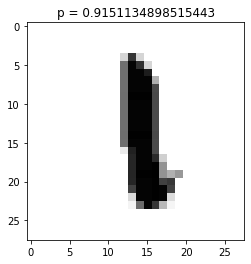

In [28]:
# Ettorna ligger sist, så sista bilden ska vara en etta.
plt.imshow(xs[-1].reshape(height, width), cmap="gray_r")
plt.title(f"p = {ps_est[-1]}")
plt.show()

Eftersom vi har skattat $\beta_0, \beta_1, \ldots, \beta_m$ kan vi också inspektera parametrarna och försöka tolka dem. Kom ihåg att vi har
$$
    \log\left(\frac{p_i}{1-p_i}\right) = \beta_0 + \sum_{j=1}^m \beta_j x_{ij},
$$
så sannolikheten bestäms dels av $\beta_0$, som sätter en slags nollpunkt (det värde log-oddsen får för $\mathbf{x} = 0$), samt $\beta_1, \ldots, \beta_m$, vilka kontrollerar hur log-oddsen beror på $\mathbf{x}$. Summan är ju egentligen skalärprodukten mellan vektorn $\boldsymbol{\beta} = [\beta_1, \ldots, \beta_m]^\text{T}$ och $\mathbf{x}$ – vi multiplicerar varje ”pixel” i $\boldsymbol{\beta}$ med motsvarande pixel i $\mathbf{x}$ och summerar. Detta betyder att de bilder som har nollskilda värden i pixlar där $\boldsymbol{\beta}$ är positiv ger upphov till stora log-odds medan bilder som har nollskilda värden där $\boldsymbol{\beta}$ är negativa ger upphov till små log-odds.

När vi inspekterar bilden som motsvarar $\boldsymbol{\beta}$ ser vi att den har positiva värden i mitten av bilden (där ettorna har nollskillda värden) medan den är negativ vid sidorna (där nollorna har nollskilda värden). På så sätt kan den generera stora *positiva* skalärprodukter (och därför stora log-odds) för ettor och stora *negativa* skalärprodukter (och därför små log-odds) för nollor.

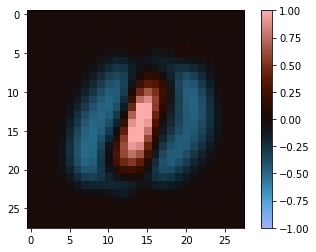

In [29]:
# Färgskalan "berlin" är en divergerande färgskala som är bra på att visa bilder
# som har både negativa och positiva pixelvärden
plt.imshow(beta_est[1:].reshape(height, width), vmin=-1, vmax=1, cmap="berlin")
plt.colorbar()
plt.show()